## **ตัวอย่างขั้นตอน Feature Selection อย่างง่าย**   


### **ชุดข้อมูล**  

บทเรียนนี้ใช้ชุดข้อมูล **'Immunotherapy.csv
'**    
&nbsp;      
ชุดข้อมูลนี้เป็นข้อมูลการรักษาผู้ป่วยโรคหูดด้วยวิธีการทางภูมิคุ้มกันบำบัด (Immunotherapy)
&nbsp;    
โดยมีการดัดแปลงข้อมูลมาจาก:  
Khozeimeh F, Jabbari Azad F, Mahboubi Oskouei Y, Jafari M, Tehranian S, Alizadehsani R, Layegh P. Intralesional immunotherapy compared to cryotherapy in the treatment of warts. *International journal of dermatology*. 2017 Apr;56(4):474-8.

***ชุดข้อมูล 'Immunotherapy.csv' มีรายละเอียดดังนี้:***  

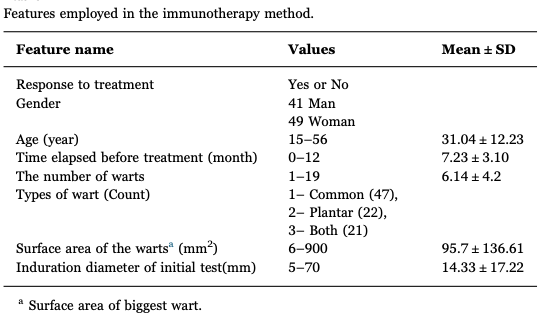

### **การอ่านชุดข้อมูล**  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/Immunotherapy.csv")
df

,gender,age,time,number_of_warts,type,area,induration_diameter,response
0,Female,15,1.75,1,Plantar,49,7,No
1,Female,38,2.50,1,Both,43,50,Yes
2,Female,24,4.25,1,common,174,30,Yes
3,Female,34,8.50,1,Plantar,163,7,No
4,Female,53,10.00,1,Plantar,30,25,Yes
...,...,...,...,...,...,...,...,...
85,Male,22,2.25,14,Both,51,50,Yes
86,Male,38,12.00,14,common,87,6,No
87,Female,47,3.75,14,Plantar,67,50,Yes
88,Female,20,7.75,18,Both,45,2,Yes


&nbsp;  
### **การจัดเตรียมข้อมูล**  


&nbsp;  
<span style="color:#275bb0">**Adjust data type**</span>

In [3]:
df = df.astype({
    'gender': 'category',
    'type': 'category',
    'response': 'category'
})

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               90 non-null     category
 1   age                  90 non-null     int64   
 2   time                 90 non-null     float64 
 3   number_of_warts      90 non-null     int64   
 4   type                 90 non-null     category
 5   area                 90 non-null     int64   
 6   induration_diameter  90 non-null     int64   
 7   response             90 non-null     category
dtypes: category(3), float64(1), int64(4)
memory usage: 4.3 KB


In [5]:
categorical_cols = df.select_dtypes(include=['category']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
df

,age,time,number_of_warts,area,induration_diameter,gender_Male,type_Plantar,type_common,response_Yes
0,15,1.75,1,49,7,0,1,0,0
1,38,2.50,1,43,50,0,0,0,1
2,24,4.25,1,174,30,0,0,1,1
3,34,8.50,1,163,7,0,1,0,0
4,53,10.00,1,30,25,0,1,0,1
...,...,...,...,...,...,...,...,...,...
85,22,2.25,14,51,50,1,0,0,1
86,38,12.00,14,87,6,1,0,1,0
87,47,3.75,14,67,50,0,1,0,1
88,20,7.75,18,45,2,0,0,0,1


\
Class 1: survive  
Class 0: not survive

&nbsp;  
<span style="color:#275bb0">**Separate data and label**</span>


X: Data (features)  
y: Label (outcome)

In [6]:
X = df.loc[:,~(df.columns=='response_Yes')]
print(X.shape)
X.head()

(90, 8)


,age,time,number_of_warts,area,induration_diameter,gender_Male,type_Plantar,type_common
0,15,1.75,1,49,7,0,1,0
1,38,2.50,1,43,50,0,0,0
2,24,4.25,1,174,30,0,0,1
3,34,8.50,1,163,7,0,1,0
4,53,10.00,1,30,25,0,1,0


In [7]:
y = df.response_Yes
print(y.shape)
y

(90,)


,response_Yes
0,0
1,1
2,1
3,0
4,1
...,...
85,1
86,0
87,1
88,1


&nbsp;  
<span style="color:#275bb0">**Train-test split**</span>

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1234)

\
Reset all indices to start from 0 to avoid further confusion.

In [9]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

&nbsp;  
<span style="color:#275bb0">**Feature data scaling**</span>

In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)

MinMaxScaler()

\
Performing feature data scaling:

\
Scale training set:

In [11]:
X_train_sc = scaler.transform(X_train)
X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)

In [12]:
X_train_sc

,age,time,number_of_warts,area,induration_diameter,gender_Male,type_Plantar,type_common
0,0.463415,0.363636,0.333333,0.064877,0.073529,1.0,0.0,0.0
1,0.195122,0.431818,0.055556,0.041387,0.073529,1.0,0.0,1.0
2,0.195122,0.181818,0.055556,0.090604,1.000000,1.0,0.0,0.0
3,0.000000,0.909091,0.277778,0.026846,0.338235,1.0,0.0,1.0
4,0.121951,0.613636,0.944444,0.043624,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
58,0.024390,0.090909,0.555556,0.045861,0.073529,0.0,0.0,1.0
59,0.024390,0.818182,0.333333,0.153244,0.058824,0.0,0.0,1.0
60,0.756098,0.954545,0.166667,0.095078,0.338235,1.0,0.0,1.0
61,0.951220,0.590909,0.666667,0.041387,0.044118,1.0,0.0,0.0


\
Scale test set:

In [13]:
X_test_sc = scaler.transform(X_test)
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)

In [14]:
X_test_sc

,age,time,number_of_warts,area,induration_diameter,gender_Male,type_Plantar,type_common
0,0.487805,0.522727,0.166667,0.039150,0.088235,1.0,0.0,0.0
1,0.731707,0.818182,0.388889,0.058166,0.073529,1.0,0.0,1.0
2,0.609756,0.409091,0.388889,0.070470,0.044118,1.0,0.0,0.0
3,0.414634,1.000000,0.277778,0.032438,0.044118,0.0,0.0,0.0
4,0.097561,0.113636,0.388889,0.040268,1.000000,0.0,1.0,0.0
5,0.780488,0.750000,0.666667,0.403803,0.088235,0.0,1.0,0.0
6,0.219512,0.340909,0.500000,0.026846,0.632353,0.0,0.0,0.0
7,0.170732,0.659091,0.444444,0.387025,0.014706,0.0,0.0,1.0
8,0.024390,0.863636,0.055556,0.105145,0.338235,1.0,0.0,1.0
9,0.512195,0.068182,0.500000,0.043624,0.014706,0.0,0.0,0.0


&nbsp;  
### **การจัดลำดับความสำคัญของ feature ที่มีต่อตัวแปรเป้าหมายหรือ label**    
แบบจำลองเพื่อการทำนายจะมีประสิทธิภาพการทำนายได้ดีหรือไม่ดีขึ้นอยู่กับวิธีการที่ใช้ในการสร้างแบบจำลอง, คุณภาพของข้อมูลที่ใช้สร้างแบบจำลอง, พารามิเตอร์ต่างๆในการปรับจูนแบบจำลอง และ feature ที่เลือกนำมาใช้ในการสร้างแบบจำลองเพื่อการทำนาย  
  
กระบวนการเลือก feature หรือ feature selection สามารถใช้เทคนิคทางสถิติหรือ machine learning ได้หลายเทคนิค ในบทเรียนนี้จะยกตัวอย่างการประยุกต์ใช้ Random Forest (RF) ในการหาค่าความสำคัญของ feature ที่มีต่อ label เพื่อจัดลำดับ feature ที่มีความสำคัญมากสุดไปน้อยสุด ในที่นี้ label คือ ข้อมูลคอลัมน์ response



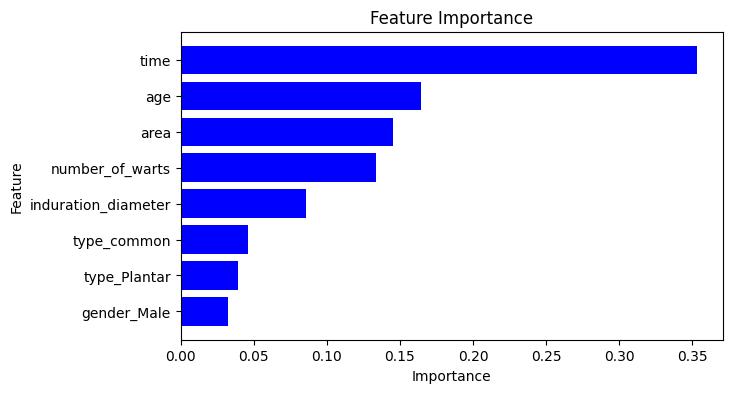

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest classifier
rf = RandomForestClassifier()

# Fit the classifier to the data
rf.fit(X_train_sc, y_train)

# Get the feature importances
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})

# Sort the features by importance
feature_importances = feature_importances.sort_values('importance', ascending=False)

# Display the feature importances
import matplotlib.pyplot as plt

# Sort the features by importance
feature_importances = feature_importances.sort_values('importance', ascending=True)

# Create a bar plot
plt.figure(figsize=(7, 4))
plt.barh(feature_importances['feature'], feature_importances['importance'], color='blue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

### เทคนิค Feature selection อื่นๆ https://scikit-learn.org/stable/modules/feature_selection.html

&nbsp;  
### **การคัดเลือก feature**    
ในบทนี้นิสิตจะได้ทำการเลือก feature เพื่อนำไปสร้างแบบจำลองในการทำนาย โดยจะมี rank ของ feature จากขั้นตอนก่อนหน้าเป็น guideline ลำดับในการเลือก เช่น  

In [16]:
feature_importances = feature_importances.sort_values('importance', ascending=False)
feature_importances

,feature,importance
1,time,0.353521
0,age,0.164386
3,area,0.145383
2,number_of_warts,0.133530
4,induration_diameter,0.085484
7,type_common,0.045843
6,type_Plantar,0.039536
5,gender_Male,0.032318


In [17]:
# เลือก time ถึง number_of_warts
X_train_sc_sel = X_train[feature_importances.feature[0:5]]
X_train_sc_sel

,time,age,area,number_of_warts,induration_diameter
0,5.00,34,64,7,7
1,5.75,23,43,2,7
2,3.00,23,87,2,70
3,11.00,15,30,6,25
4,7.75,20,45,18,2
...,...,...,...,...,...
58,2.00,16,47,11,7
59,10.00,16,143,7,6
60,11.50,46,91,4,25
61,7.50,54,43,13,5


In [18]:
from sklearn.neural_network import MLPClassifier
ann = MLPClassifier(hidden_layer_sizes=(14, 28, 14, 7, 3),
                    activation='relu',
                    solver='adam',
                    random_state=1234, # random number generation for weights and bias initialization
                    learning_rate='adaptive',
                    max_iter=3000
                   )

In [19]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=1234)

In [20]:
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(estimator=ann,
                           X=X_train_sc_sel,
                           y=y_train,
                           cv=skf)

### <span style="color:red">หมายเหตุ: ให้นิสิตทำการ tune parameter ต่างๆ เอง</span>

\
Display training confusion matrix:

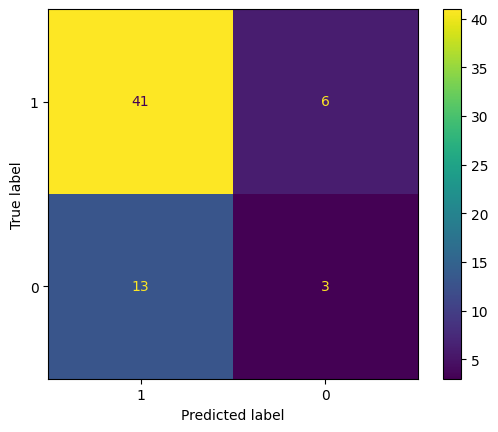

In [21]:
conf_mat = metrics.confusion_matrix(y_train, y_pred, labels=[1,0])
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=[1,0]).plot()

\
Get training performance scores:

In [22]:
acc = metrics.accuracy_score(y_train, y_pred)
precision = metrics.precision_score(y_train, y_pred)
recall = metrics.recall_score(y_train, y_pred)
f1 = metrics.f1_score(y_train, y_pred)
auc = metrics.roc_auc_score(y_train, y_pred)

print(f"acc={acc:.2f}")
print(f"precision={precision:.2f}")
print(f"recall={recall:.2f}")
print(f"f1={f1:.2f}")
print(f"auc: {auc:.2f}\n")

acc=0.70
precision=0.76
recall=0.87
f1=0.81
auc: 0.53



\
ทดสอบ test set:

In [23]:
ann = MLPClassifier(hidden_layer_sizes=(14, 28, 14, 7, 3),
                    activation='relu',
                    solver='adam',
                    random_state=1234,
                    learning_rate='adaptive',
                    max_iter=3000)
ann.fit(X=X_train_sc, y=y_train)

MLPClassifier(hidden_layer_sizes=(14, 28, 14, 7, 3), learning_rate='adaptive',
              max_iter=3000, random_state=1234)

In [24]:
y_pred_test = ann.predict(X_test_sc)
y_pred_test

array([0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1])

\
Display confusion matrix:

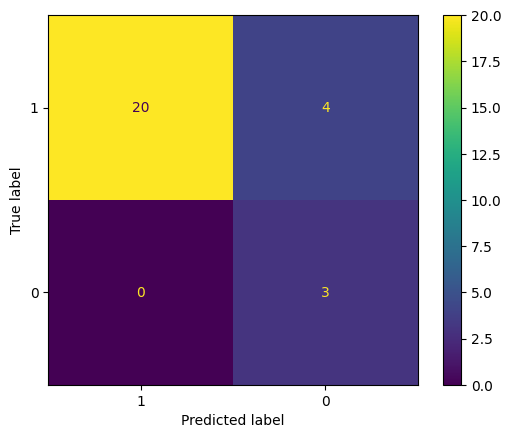

In [25]:
conf_mat = metrics.confusion_matrix(y_test, y_pred_test, labels=[1,0])
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=[1,0]).plot()

\
Evaluate model performance scores based on test set:

In [26]:
acc = metrics.accuracy_score(y_test, y_pred_test)
precision = metrics.precision_score(y_test, y_pred_test)
recall = metrics.recall_score(y_test, y_pred_test)
f1 = metrics.f1_score(y_test, y_pred_test)
matw = metrics.matthews_corrcoef(y_test, y_pred_test)
auc = metrics.roc_auc_score(y_test, y_pred_test)

print(f"Test set performance scores:\n"
      f"accuracy: {acc:.2f}\n"
      f"precision: {precision:.2f}\n"
      f"recall: {recall:.2f}\n"
      f"f1: {f1:.2f}\n"
      f"auc: {auc:.2f}\n"
      f"Matthew's corr coef: {matw:.2f}\n"
     )

Test set performance scores:
accuracy: 0.85
precision: 1.00
recall: 0.83
f1: 0.91
auc: 0.92
Matthew's corr coef: 0.60

